# Pitch Vision - Football Player and Ball Detection
## Análisis de Datos No Estructurados
### Raúl Jimeno y Ruben Navarro

## 2. Classical Machine Learning Baseline

Object detection requires both classifying and localising objects simultaneously, which is beyond what a standard classifier can do. However, an honest non-deep-learning baseline is still useful: it establishes a performance floor, validates that the image features carry discriminative signal, and provides a reference against which the YOLO models can be compared.

The approach reframes detection as **crop-level classification**: ground-truth bounding boxes are used to cut object crops from training images, HOG features are extracted from each crop, and a Linear SVM is trained to distinguish `ball` from `player`. The same crops are extracted from the validation set for evaluation.

This is not a detector — it cannot find objects in new images. It only answers: *given a correctly localised crop, can a classical model distinguish the two classes?*

### 2.1 Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from pitch_vision.classical_ml import (
    build_crop_feature_table,
    evaluate_classifier,
    train_svm_baseline,
)
from pitch_vision.dataset import collect_annotations

RAW_ROOT    = PROJECT_ROOT / 'data'
OUTPUT_DIR  = PROJECT_ROOT / 'outputs' / 'eda'
CLASS_NAMES = {0: 'ball', 1: 'player'}

sns.set_theme(style='whitegrid', font_scale=1.1)
print('Setup complete.')

Setup complete.


### 2.2 Data Preparation

In [2]:
annotations = collect_annotations(RAW_ROOT)
train_ann   = annotations[annotations['split'] == 'train']
val_ann     = annotations[annotations['split'] == 'val']

# Cap at 1500 crops per class to keep training tractable on CPU
x_train, y_train = build_crop_feature_table(train_ann, max_per_class=1500)
x_val,   y_val   = build_crop_feature_table(val_ann)

import numpy as np
for name, y in [('train', y_train), ('val', y_val)]:
    unique, counts = np.unique(y, return_counts=True)
    print(f'{name}: {dict(zip([CLASS_NAMES[int(u)] for u in unique], counts))}')
print(f'\nFeature vector size: {x_train.shape[1]} dimensions')

train: {'ball': np.int64(1500), 'player': np.int64(1500)}
val: {'ball': np.int64(275), 'player': np.int64(5132)}

Feature vector size: 3780 dimensions


>- Training is capped at **1,500 crops per class** to ensure a balanced training set and keep compute tractable on CPU. Despite the original dataset containing 20x more player than ball annotations, the SVM sees equal numbers of each during training.
>- The validation set is left unmodified: **275 ball crops** and **5,132 player crops** — a 1:19 imbalance that reflects real-world distribution and will penalise ball recall without `class_weight='balanced'`.
>- Each crop is resized to 64×128 px and described by a **HOG (Histogram of Oriented Gradients)** feature vector. HOG encodes local edge orientations in overlapping cell blocks, producing a **3,780-dimensional** descriptor that is robust to small translations and illumination changes.

### 2.3 Model Training

In [3]:
model = train_svm_baseline(x_train, y_train)
print('Linear SVM trained.')
print(model)

Linear SVM trained.
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LinearSVC(class_weight='balanced', max_iter=10000,
                           random_state=42))])


>- A **Linear SVM** with balanced class weights is used. The `class_weight='balanced'` option compensates for the imbalance between ball and player crops by upweighting the minority class during training.
>- Features are standardised with `StandardScaler` before training — essential for SVMs, which are sensitive to feature scale.

### 2.4 Evaluation

In [4]:
report = evaluate_classifier(
    model,
    x_val,
    y_val,
    CLASS_NAMES,
    OUTPUT_DIR / 'classical_ml_confusion_matrix.png',
)
print(report)

              precision    recall  f1-score   support

        ball       0.52      0.82      0.64       275
      player       0.99      0.96      0.97      5132

    accuracy                           0.95      5407
   macro avg       0.76      0.89      0.81      5407
weighted avg       0.97      0.95      0.96      5407



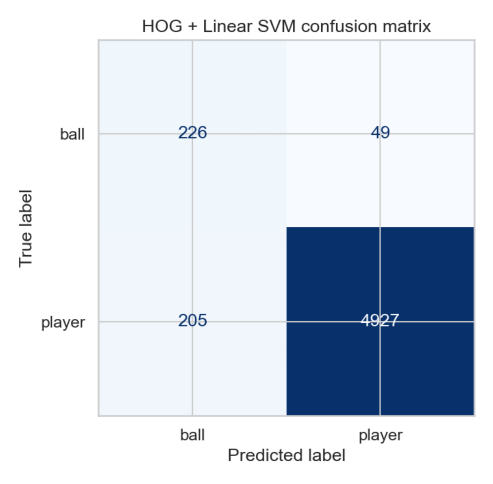

In [5]:
cm_path = OUTPUT_DIR / 'classical_ml_confusion_matrix.png'
if cm_path.exists():
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(mpimg.imread(cm_path))
    ax.axis('off')
    plt.tight_layout()
    plt.show()

>- **Player F1: 0.97** — as expected, player crops are large and structurally consistent. The upright human silhouette produces a highly discriminative HOG signature, and the model classifies them almost perfectly (precision 0.99, recall 0.96).
>- **Ball F1: 0.64** — performance is substantially lower. Precision is only 0.52, meaning roughly half of the crops the SVM labels as "ball" are actually players or background. The high recall (0.82) shows the model casts a wide net, but at the cost of many false positives. Ball crops are small (~21×35 px median before resizing), nearly circular, and visually ambiguous — they share white/round features with boot tips, heads, and line intersections on the pitch.
>- **Overall accuracy (0.95) is a misleading metric** due to the 19:1 class imbalance in the validation set; weighted F1 (0.96) is similarly inflated. The relevant figure is **macro F1 = 0.81**, which averages both classes equally.
>- The confusion between ball and player crops confirms that appearance-only descriptors, even with careful sampling, are insufficient for reliable small-object detection. This result sets a concrete performance floor for the YOLO comparison.

### 2.5 Limitations of the Classical Approach

>- This experiment uses **ground-truth boxes at test time** — the classifier never has to find objects, only label pre-cut crops. In a real deployment scenario it would need a sliding window or region proposal stage, which would introduce many false positives.
>- HOG operates on a **fixed scale**: the 64x128 px resize collapses all ball crops to the same size regardless of their original 3–840 px width range, destroying scale information.
>- The Linear SVM has no spatial reasoning: it treats each pixel neighbourhood independently and cannot model the relative arrangement of body parts that makes a player recognisable at different distances.
>- These limitations are structural, not parameter-tuning issues. A deep detection architecture addresses all of them simultaneously through learned multi-scale feature pyramids, which is why even a small YOLOv8n model is expected to outperform this baseline by a substantial margin.